# `sc_inj` Impact-T

In [1]:
# Nicer plotting
import matplotlib.pyplot as plt
import matplotlib
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

In [2]:
%load_ext autoreload
%autoreload 2

In [6]:
from impact import Impact
from distgen import Generator
from pmd_beamphysics import ParticleGroup, single_particle
import numpy as np

# New version
Impact.command_env     = 'NEW_IMPACTT_BIN'
Impact.command_mpi_env = 'NEW_IMPACTT_MPI_BIN'

# Distgen particles

In [7]:
DISTGEN_IN = '$LCLS_LATTICE/distgen/models/sc_inj/v0/distgen.yaml'

G = Generator(DISTGEN_IN)

G['n_particle'] = 20_000
G

<disgten.Generator with input: 
n_particle: 20000
r_dist:
  max_r:
    units: mm
    value: 0.5
  type: radial_uniform
random_type: hammersley
start:
  MTE:
    units: meV
    value: 330
  type: cathode
t_dist:
  avg_t:
    units: ps
    value: 0
  n_sigma_cutoff: 3
  sigma_t:
    units: ps
    value: 8.5
  type: gaussian
total_charge:
  units: pC
  value: 100

>

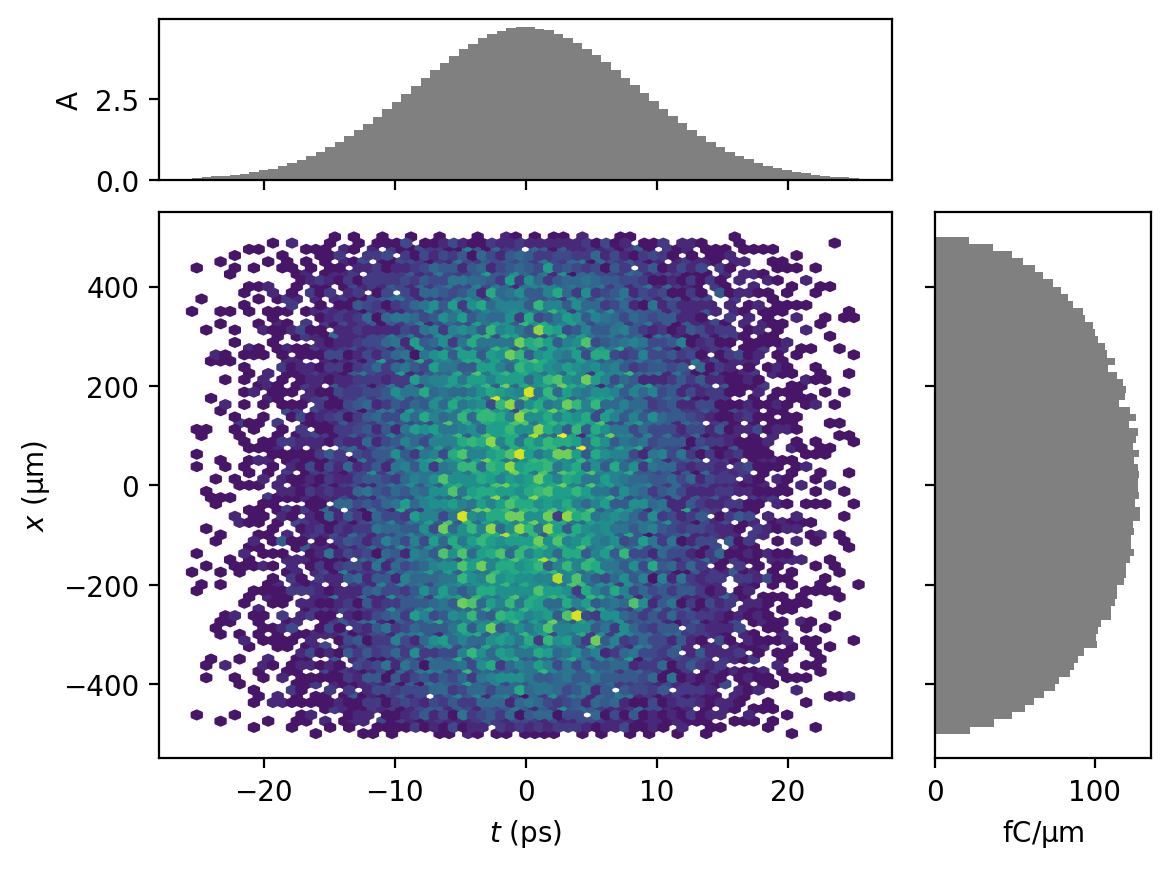

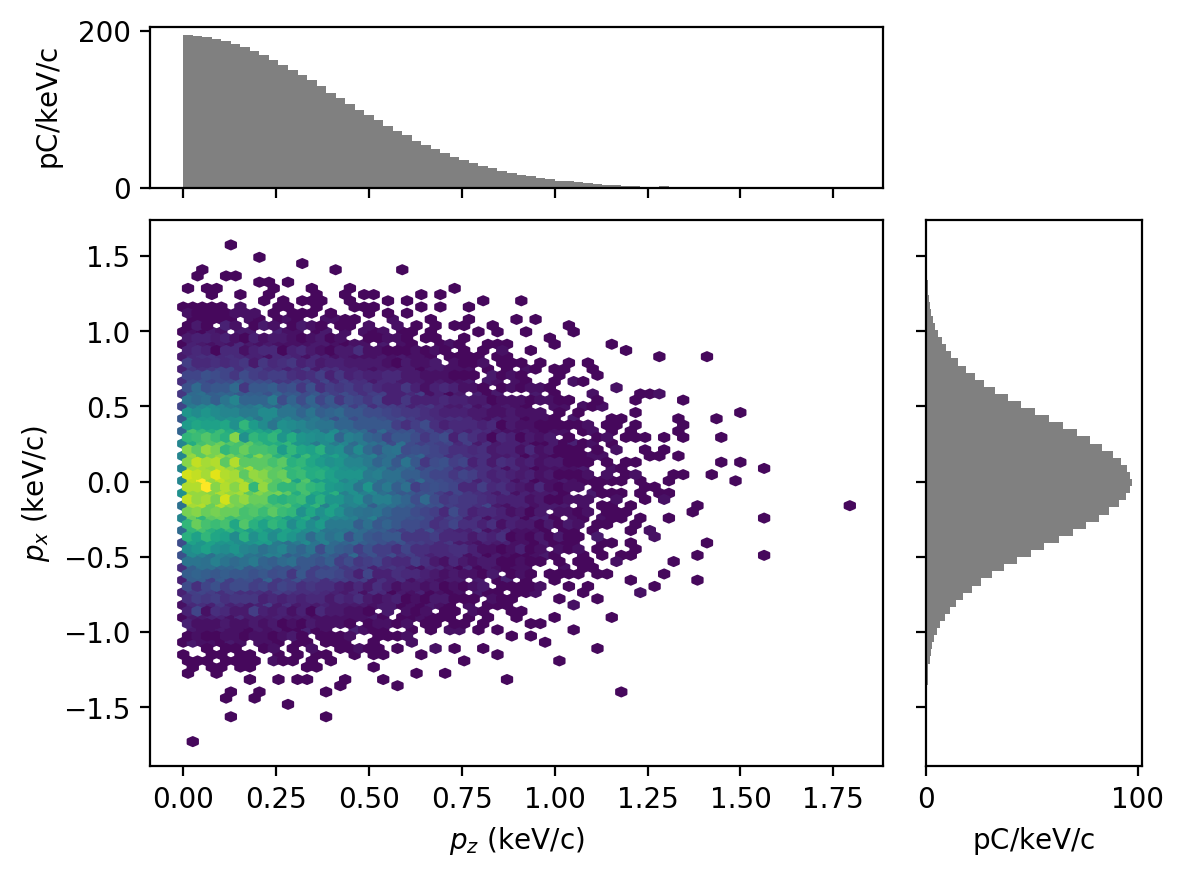

In [8]:
# Make the particles
G.run()
P0 = G.particles
P0.plot('t', 'x')
P0.plot('pz', 'px')

# V1

Setting Npcol, Nprow = 4, 2
Enabling MPI


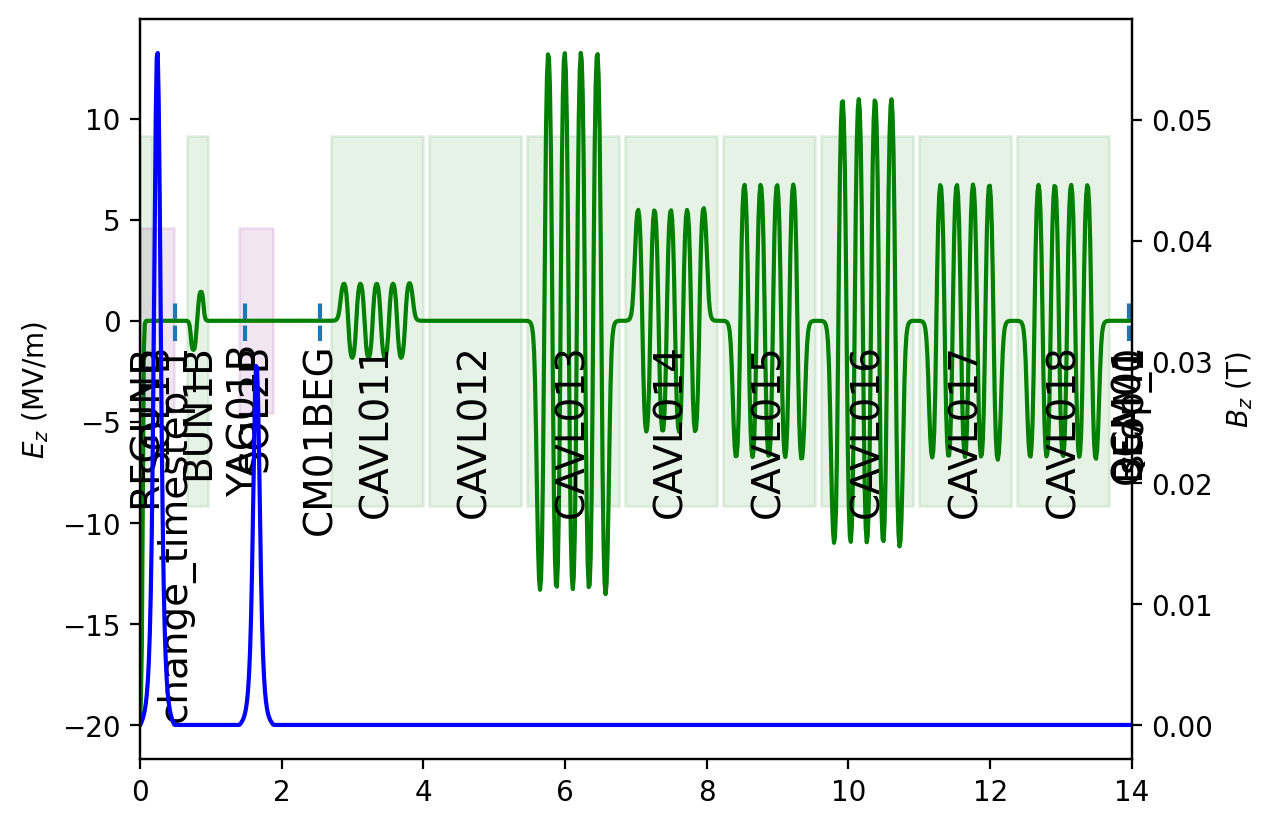

In [9]:
IMPACT_IN = '$LCLS_LATTICE/impact/models/sc_inj/v1new/ImpactT.in'

ZSTOP = 14

I = Impact(IMPACT_IN, initial_particles=P0)

I.header['Nx'] = 32
I.header['Ny'] = 32
I.header['Nz'] = 32

I.stop = ZSTOP

I.verbose=True
I.numprocs = 8

# Special setting
# I.ele['CAVL011']['theta0_deg'] = 274

#I.header['Bcurr'] = 0 # Turn off SC
I.total_charge = 100e-12

I.plot(include_labels=True, xlim=(0, ZSTOP))

In [10]:
%%time
I.run()

Running Impact-T in /var/folders/2f/l5_mybzs30j4qqvyj98w1_nw0000gn/T/tmp5hnhb9v7
mpirun -n 8 /Users/chrisonian/Code/Impact/NEW-IMPACT-T/build-mpi/ImpactTexe-mpi
writing 20000 particles to /var/folders/2f/l5_mybzs30j4qqvyj98w1_nw0000gn/T/tmp5hnhb9v7/partcl.data
Cathode start with cathode_kinetic_energy_ref = 1.0 eV
Cathode start: Replaced Np with 20000 according to initial particles
Cathode start: Replaced Bkenergy with 1.0 according to initial particles
Cathode start: Replaced Temission with 5.087364621369442e-11 according to initial particles
Cathode start: Replaced Tini with -2.546535353287743e-11 according to initial particles
Setting total charge to 9.999999999999999e-11 C
 !-----------------------------------------------------------
 ! IMPACT-T Parallel Beam Dynamics Tracking Code: V2.2
 ! Copyright of The Regents of the University of California
 !-----------------------------------------------------------
 nblem:           28          28
 pass setting up lattice...
 check randomn

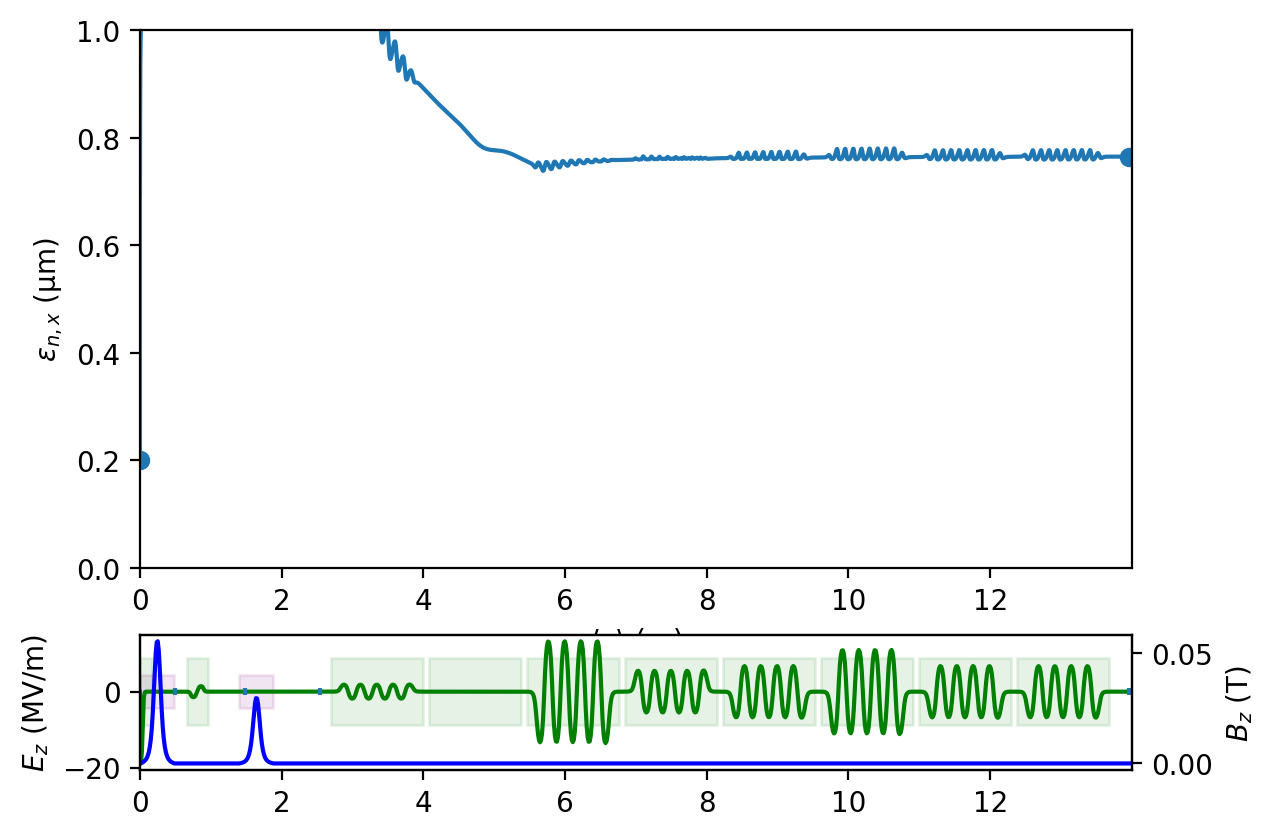

In [11]:
I.plot('norm_emit_x', ylim=(0, 1e-6))

# Plots

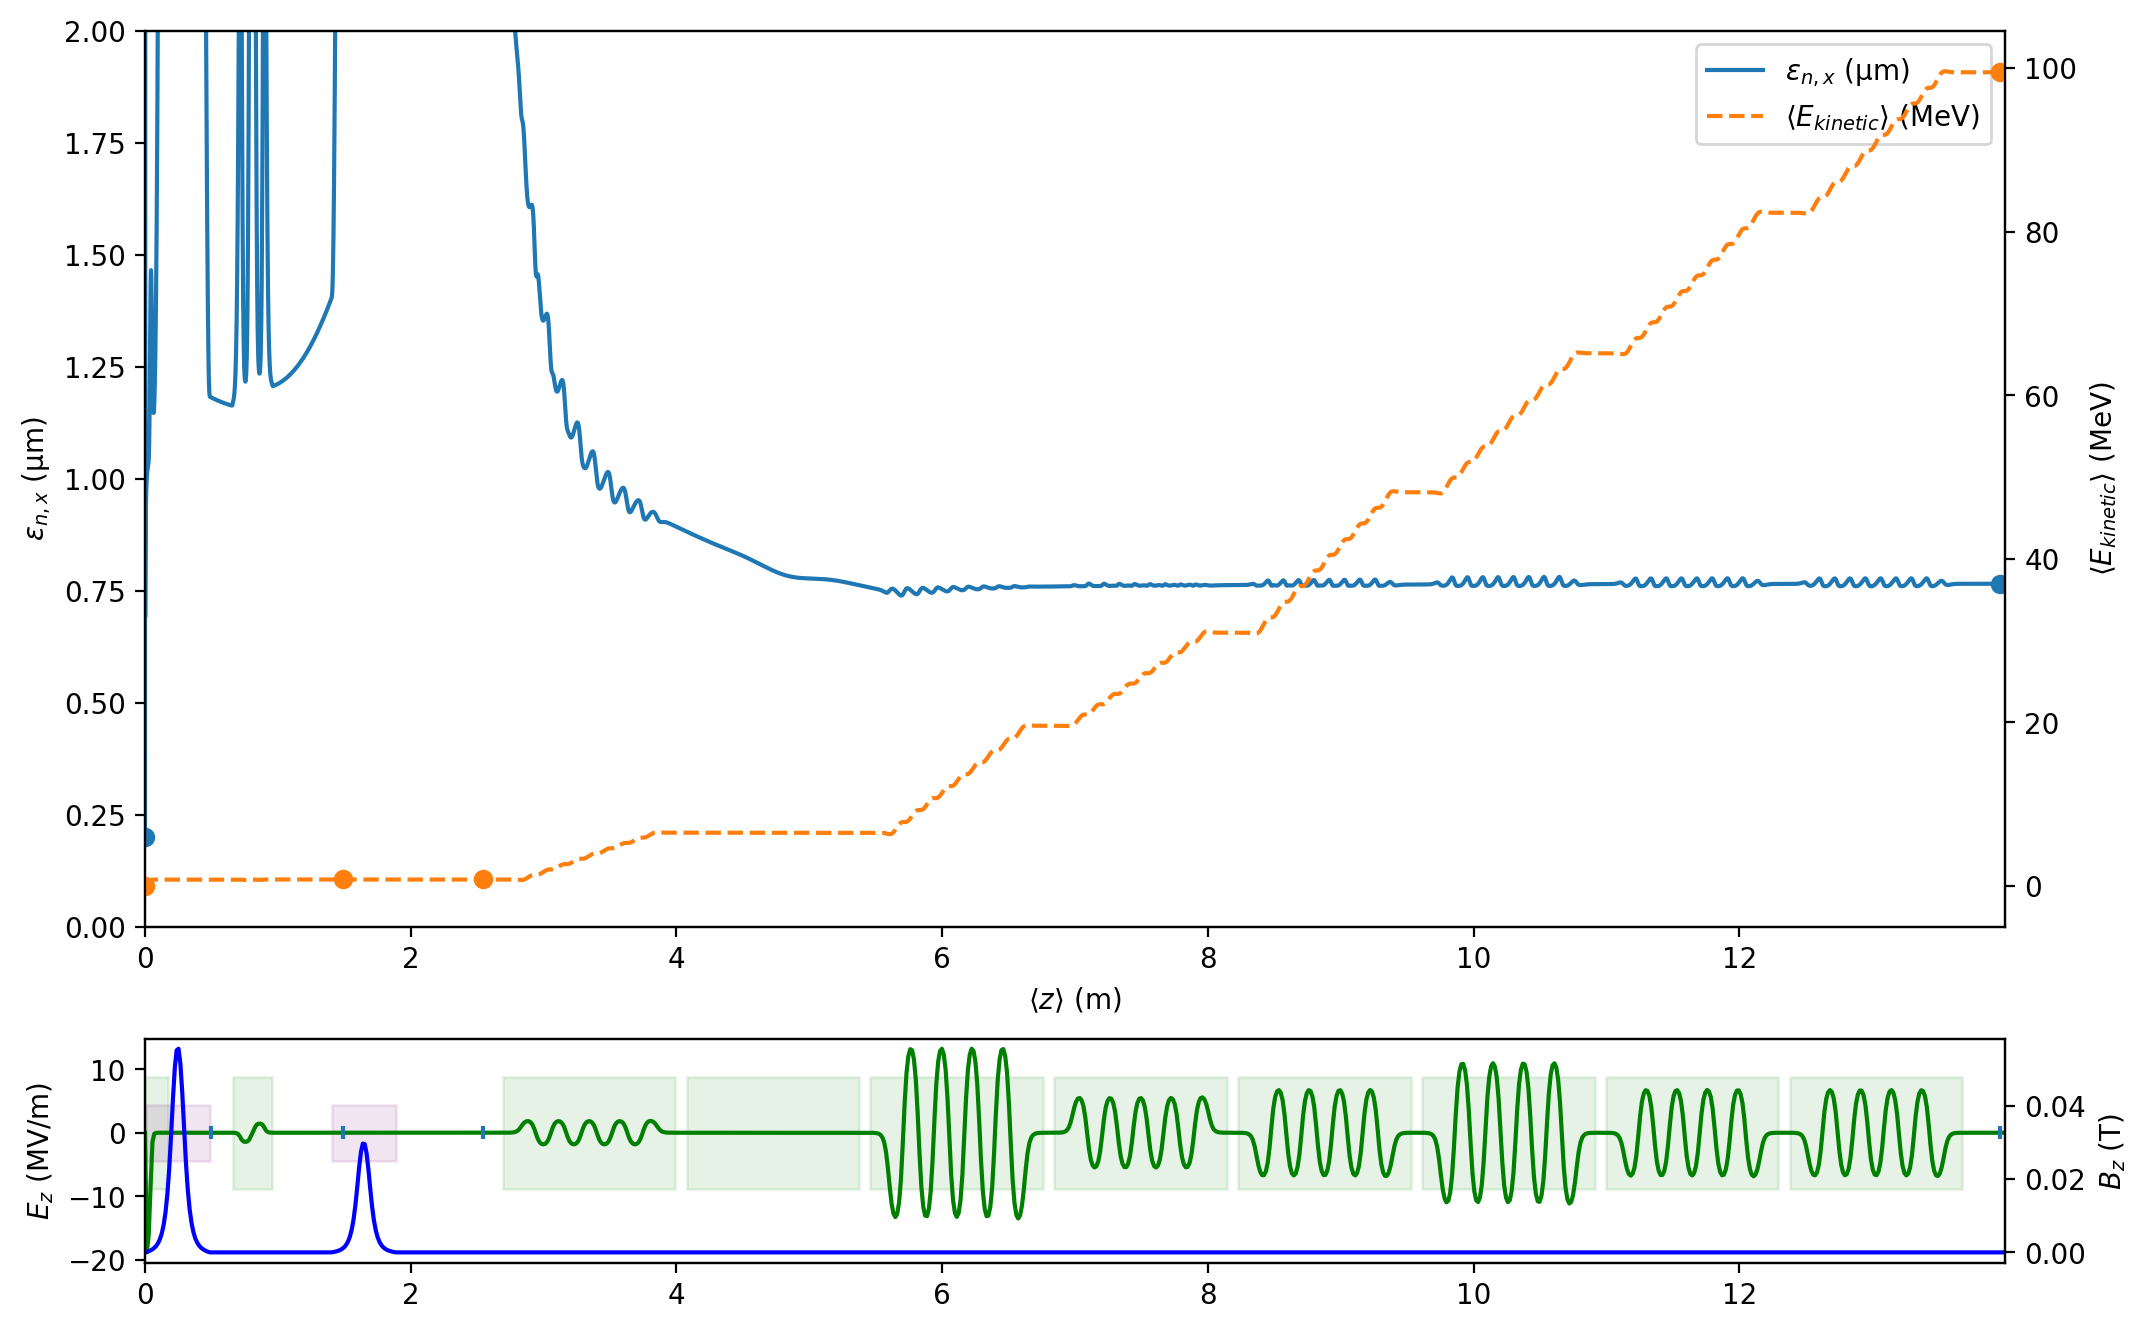

In [12]:
I.plot('norm_emit_x', y2='mean_kinetic_energy', ylim=(0, 2e-6), figsize=(12,8))

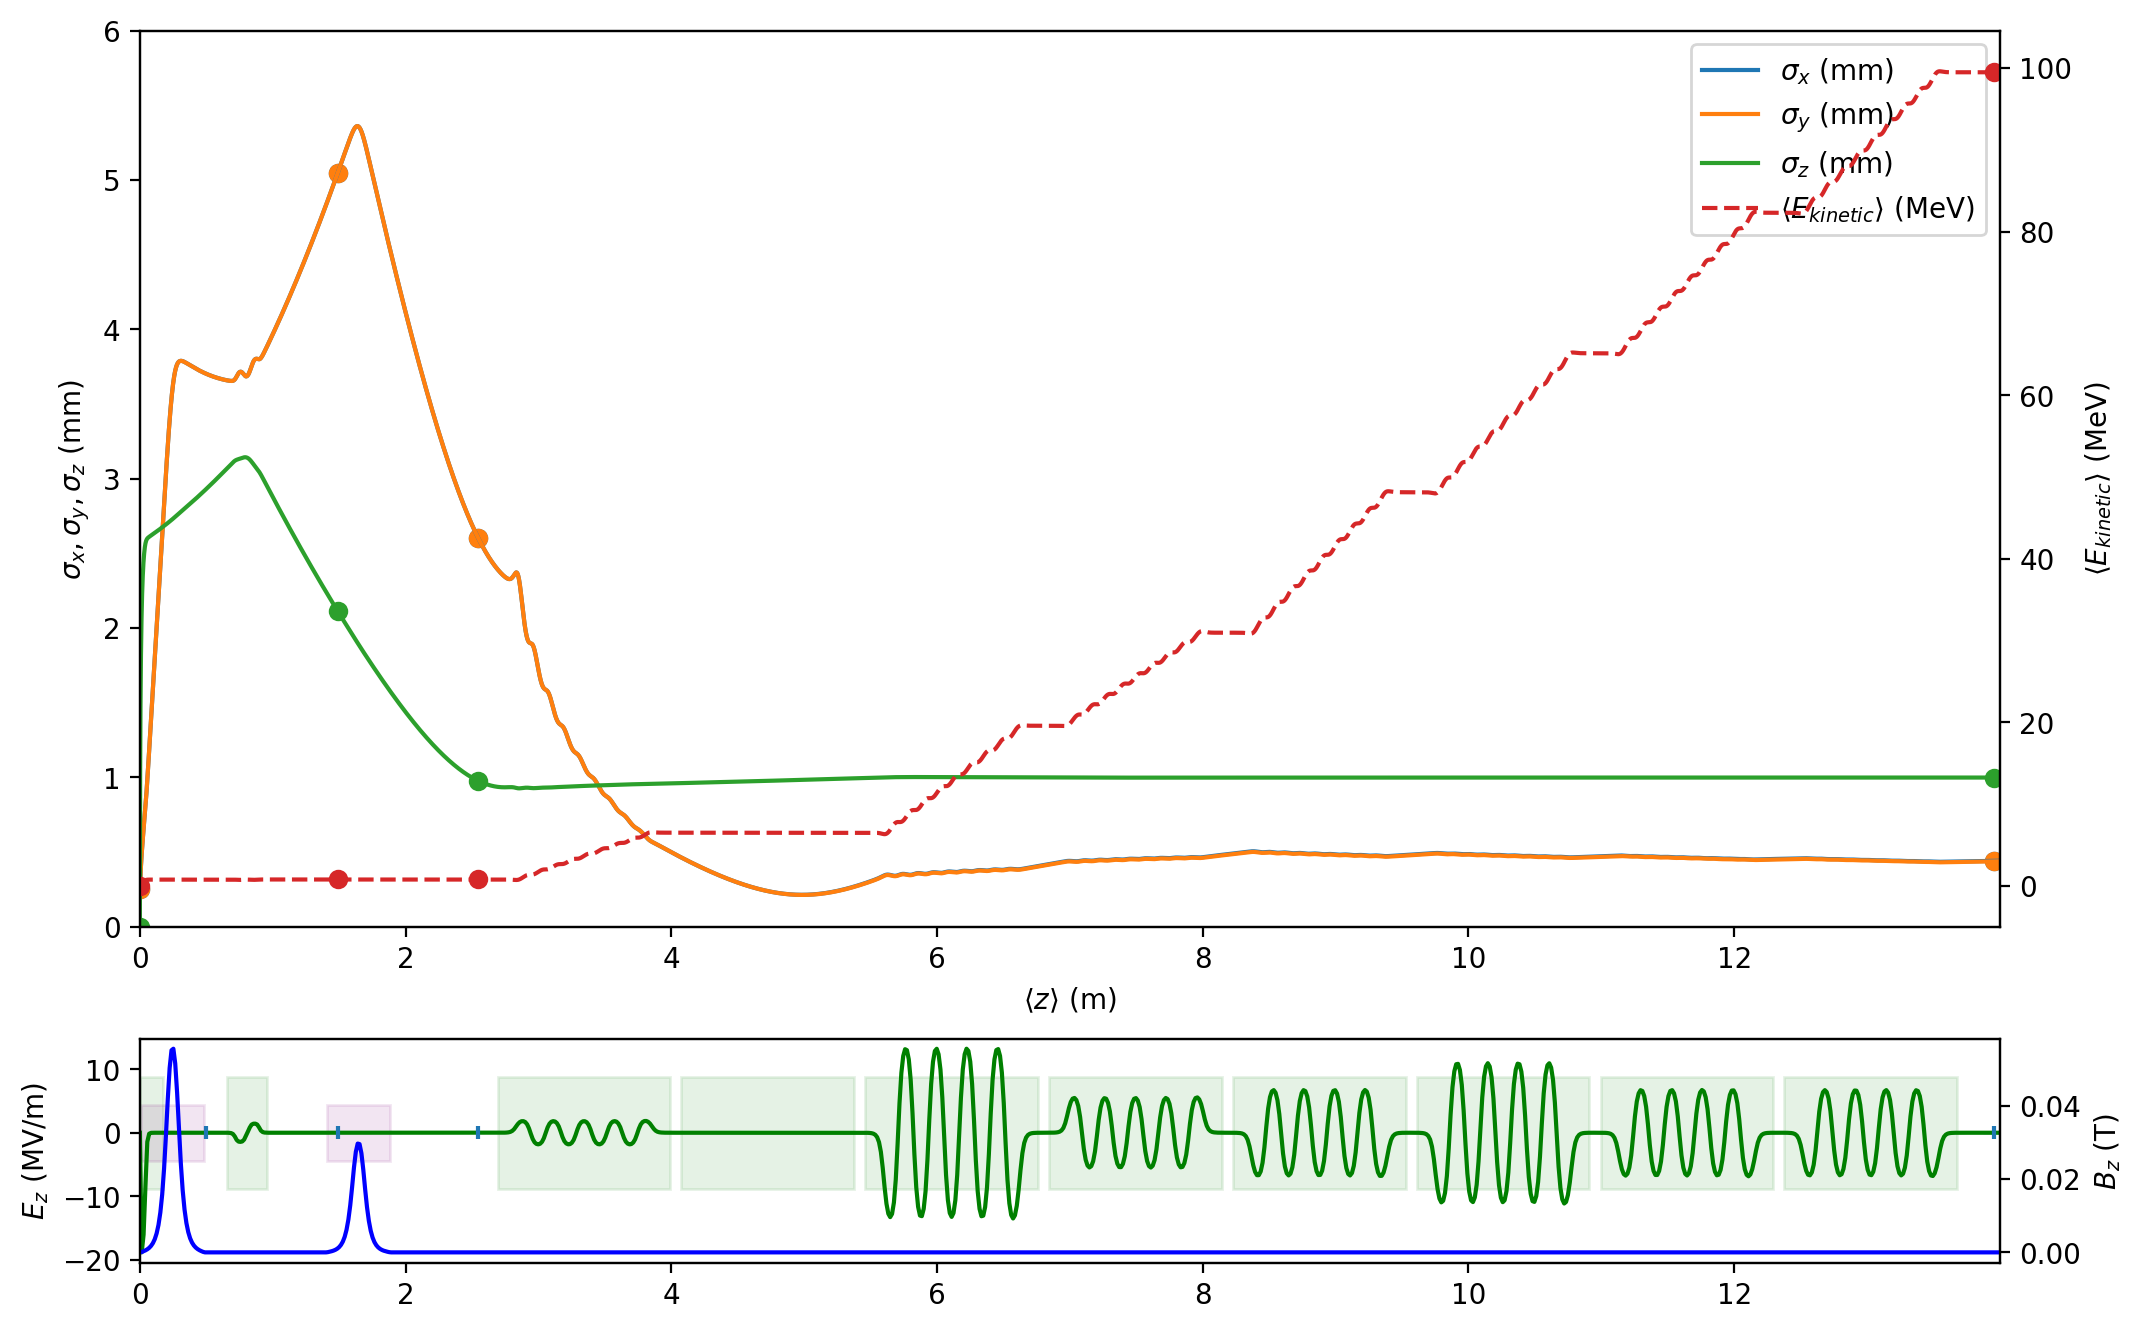

In [13]:
I.plot(['sigma_x', 'sigma_y', 'sigma_z'], y2='mean_kinetic_energy', ylim=(0, 6e-3), figsize=(12,8))

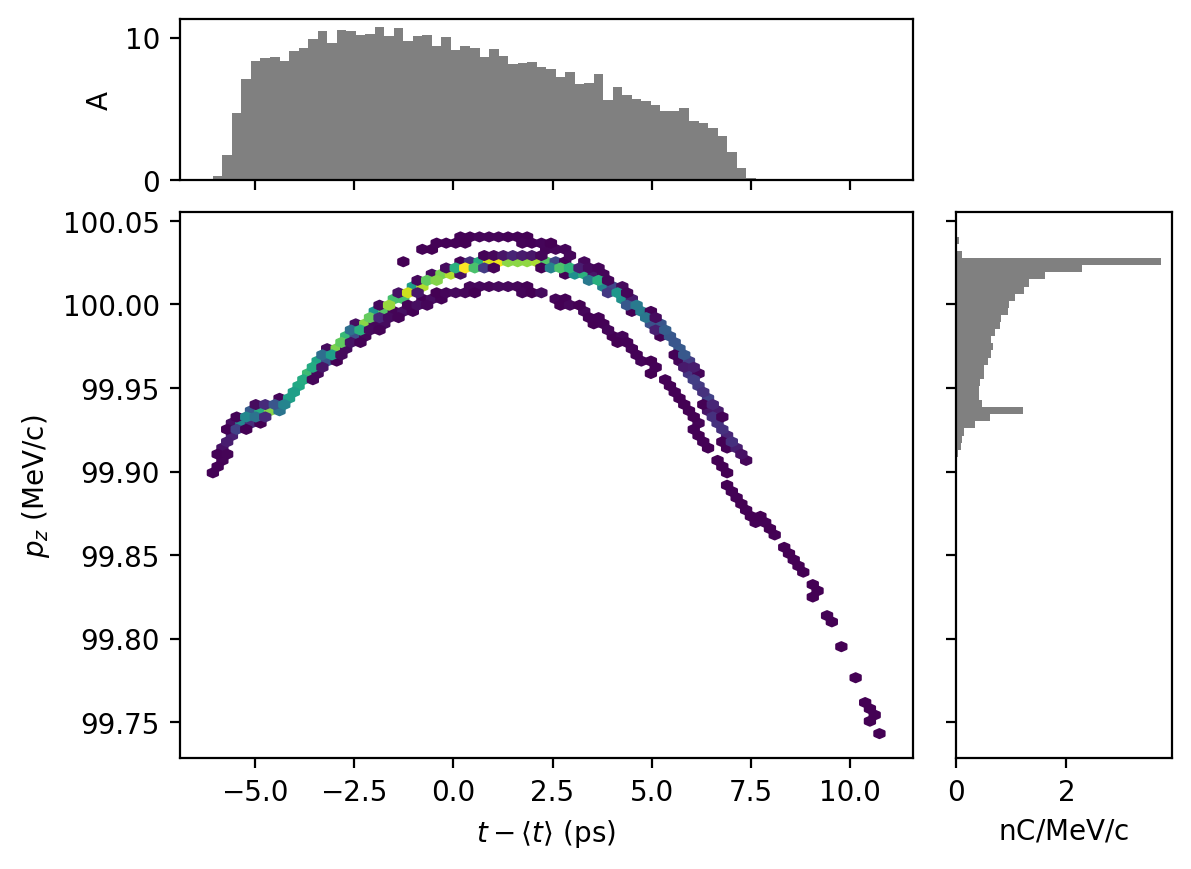

In [14]:
Pf = I.particles['BEAM0'].copy()
Pf.drift_to_z()
Pf.plot('delta_t', 'pz')

In [15]:
I.particles['BEAM0'].twiss('xy')

{'alpha_x': -1.6816954154901116,
 'beta_x': 49.51796538012386,
 'gamma_x': 0.077307285165982,
 'emit_x': 3.910373313061297e-09,
 'eta_x': 1.7530422245282236e-05,
 'etap_x': 2.7702746136967715e-05,
 'norm_emit_x': 7.651721978173536e-07,
 'alpha_y': -1.6844145603712721,
 'beta_y': 49.49908681123351,
 'gamma_y': 0.07752168087108843,
 'emit_y': 3.848871941544948e-09,
 'eta_y': 0.0005010972032323597,
 'etap_y': -7.551023844246763e-05,
 'norm_emit_y': 7.531377612445689e-07}

# Compare with Astra

In [16]:
from astra import Astra
A = Astra.from_archive('$LCLS_LATTICE/astra/models/sc_inj/v1/astra_sc_inj_v1.h5')

In [17]:
if I.header['Bcurr'] == 0:
    # Re-run without space charge
    A.input['output']['zstop'] = ZSTOP
    A.input['charge']['lspch'] = False
    A.configure()
    #A.verbose=True
    A.initial_particles = P0
    A.run()

In [18]:
A.particles[-1]['norm_emit_x']

6.413844917041914e-07

(0.0, 14.0)

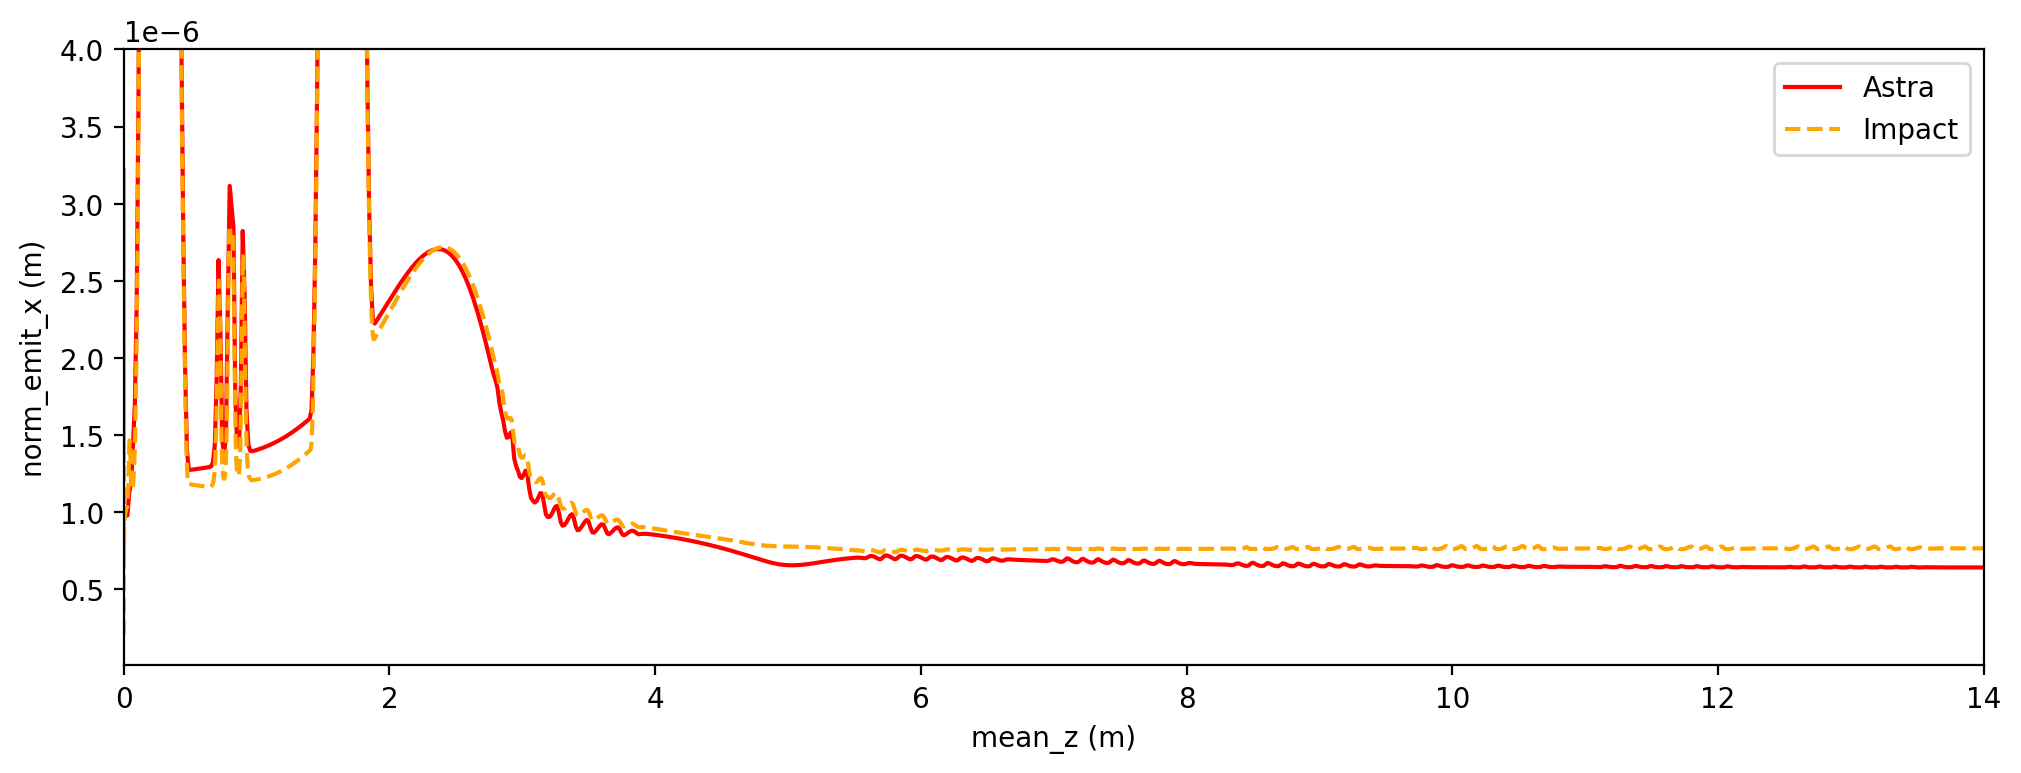

In [19]:
def compare(ykey, xkey = 'mean_z', ylim=None):
    xunits = I.units(xkey)
    yunits = I.units(ykey)
    
    fig, ax = plt.subplots(figsize=(12,4))
    
    ax.plot(A.stat(xkey), A.stat(ykey), label='Astra', color='red')
    ax.plot(I.stat(xkey), I.stat(ykey), '--', label='Impact', color='orange')
    ax.set_xlabel(f'{xkey} ({xunits})')
    ax.set_ylabel(f'{ykey} ({yunits})')
    ax.set_ylim(ylim)
    plt.legend()
    
compare('norm_emit_x', ylim=(0, 3e-6))
#plt.yscale('log')
plt.ylim(6e-9, 4e-6)
plt.xlim(0, 14)

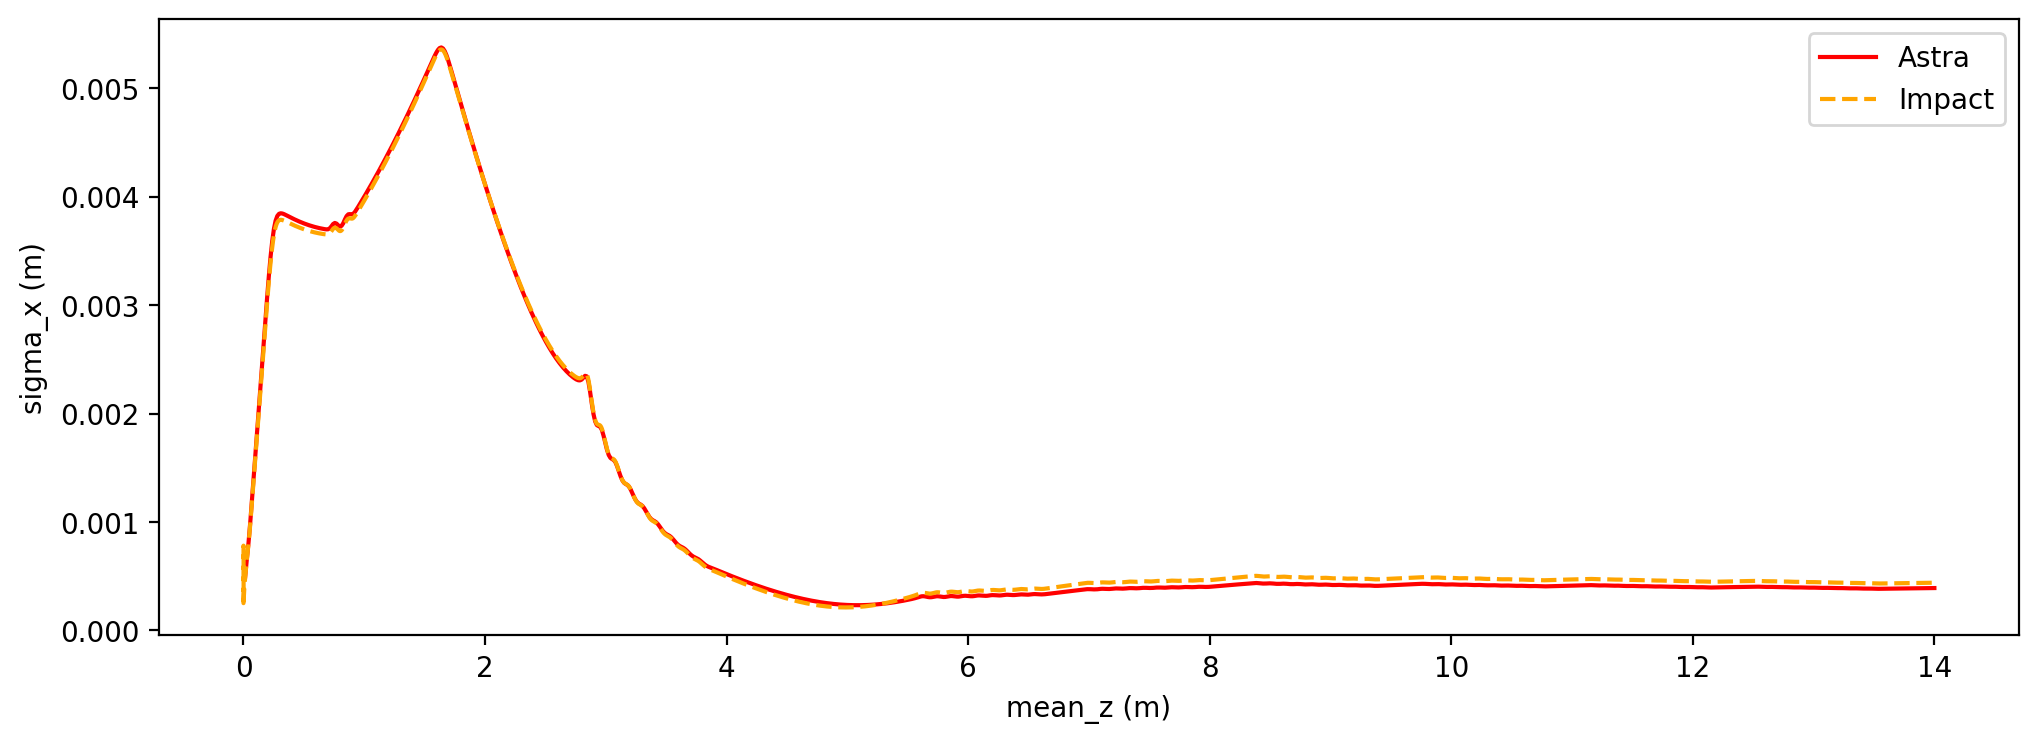

In [20]:
compare('sigma_x')

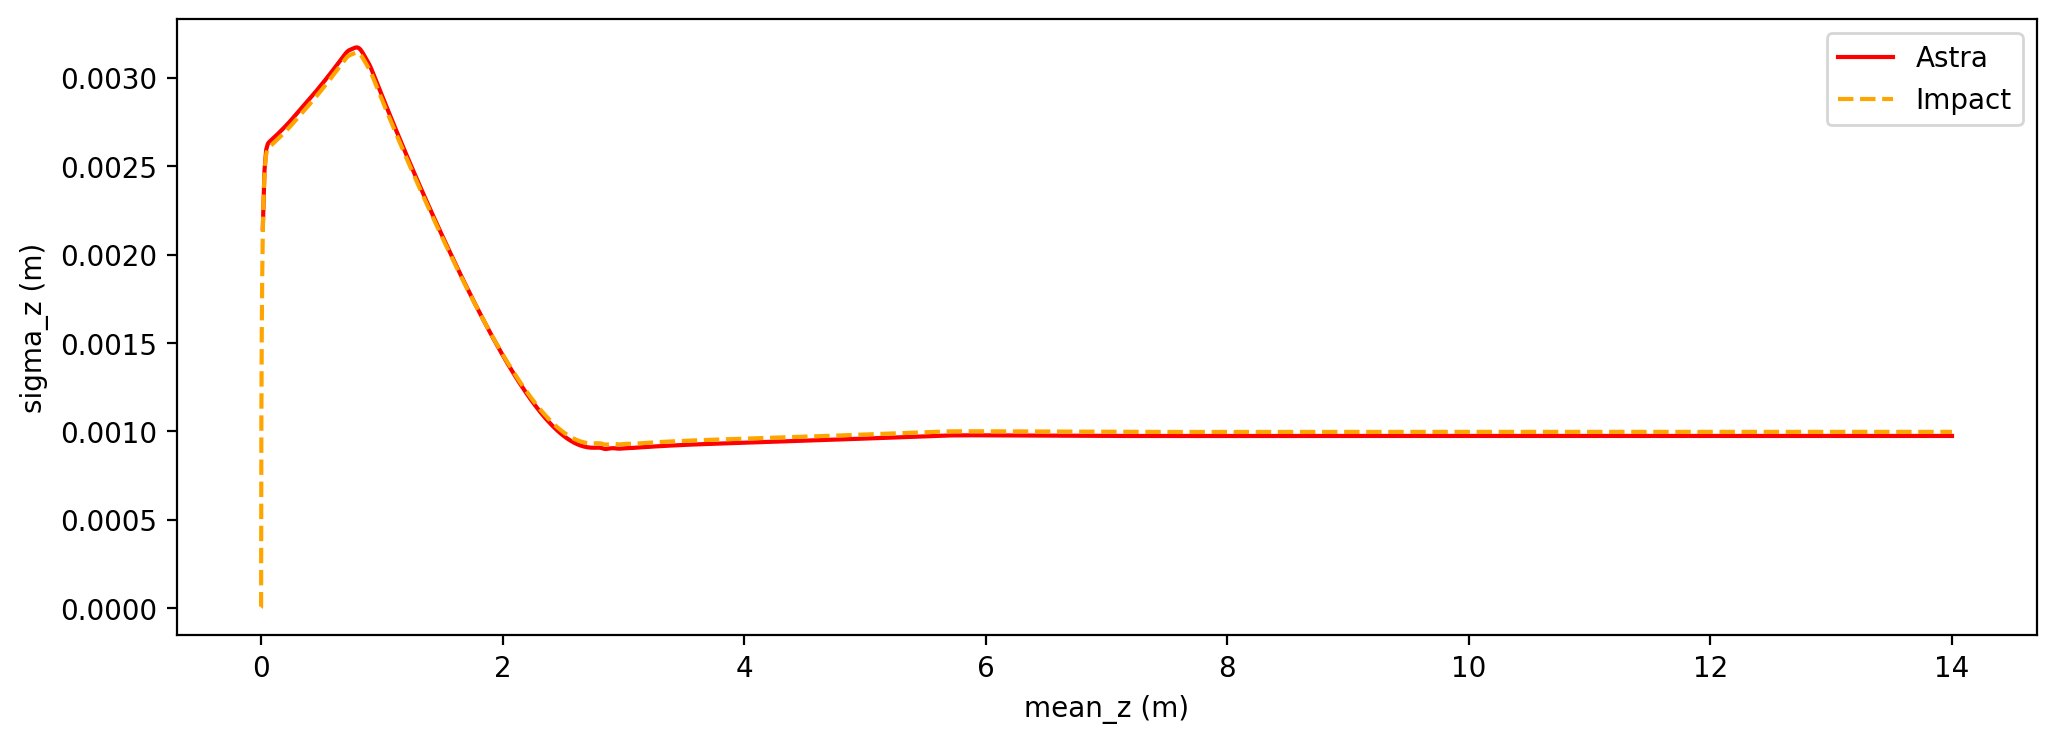

In [21]:
compare('sigma_z')

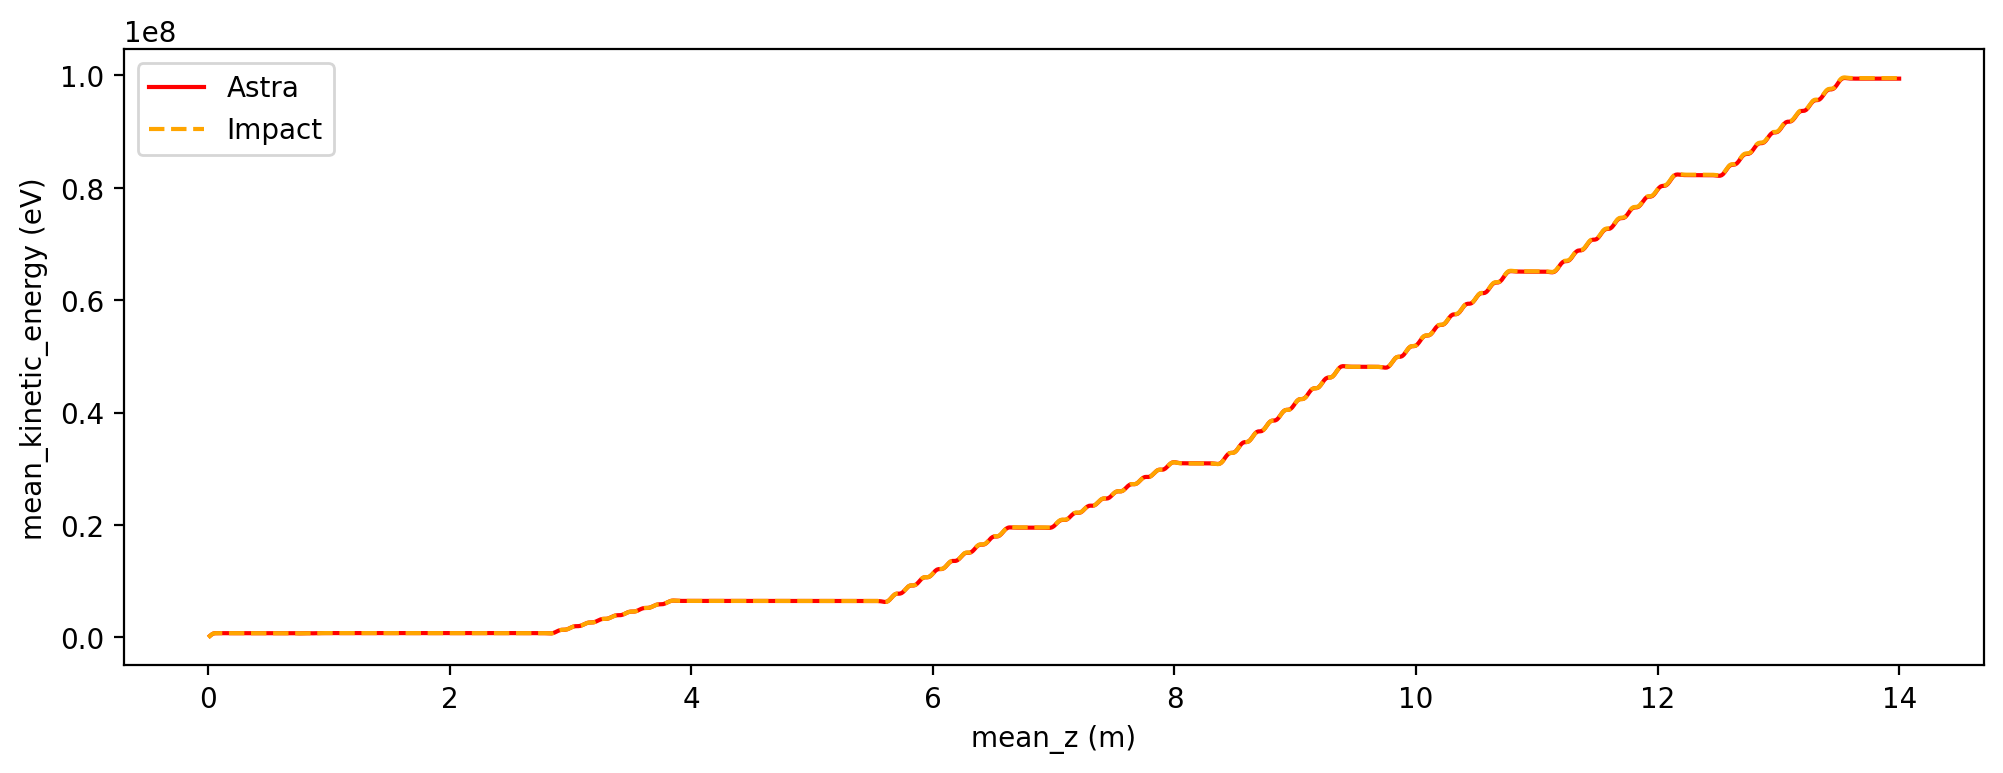

In [22]:
compare('mean_kinetic_energy')

In [23]:
Pa = A.particles[-1].copy()
Pa.drift_to_z(ZSTOP)
Pa.drift_to_t()
Pa['mean_z']

13.999999999984695

In [24]:
Pi = I.particles['final_particles'].copy()
Pi.drift_to_z(ZSTOP)
Pi.drift_to_t()
Pi['mean_z']

13.999999999996666

In [25]:
Pa['mean_energy']/Pi['mean_energy']

0.9990876210523538

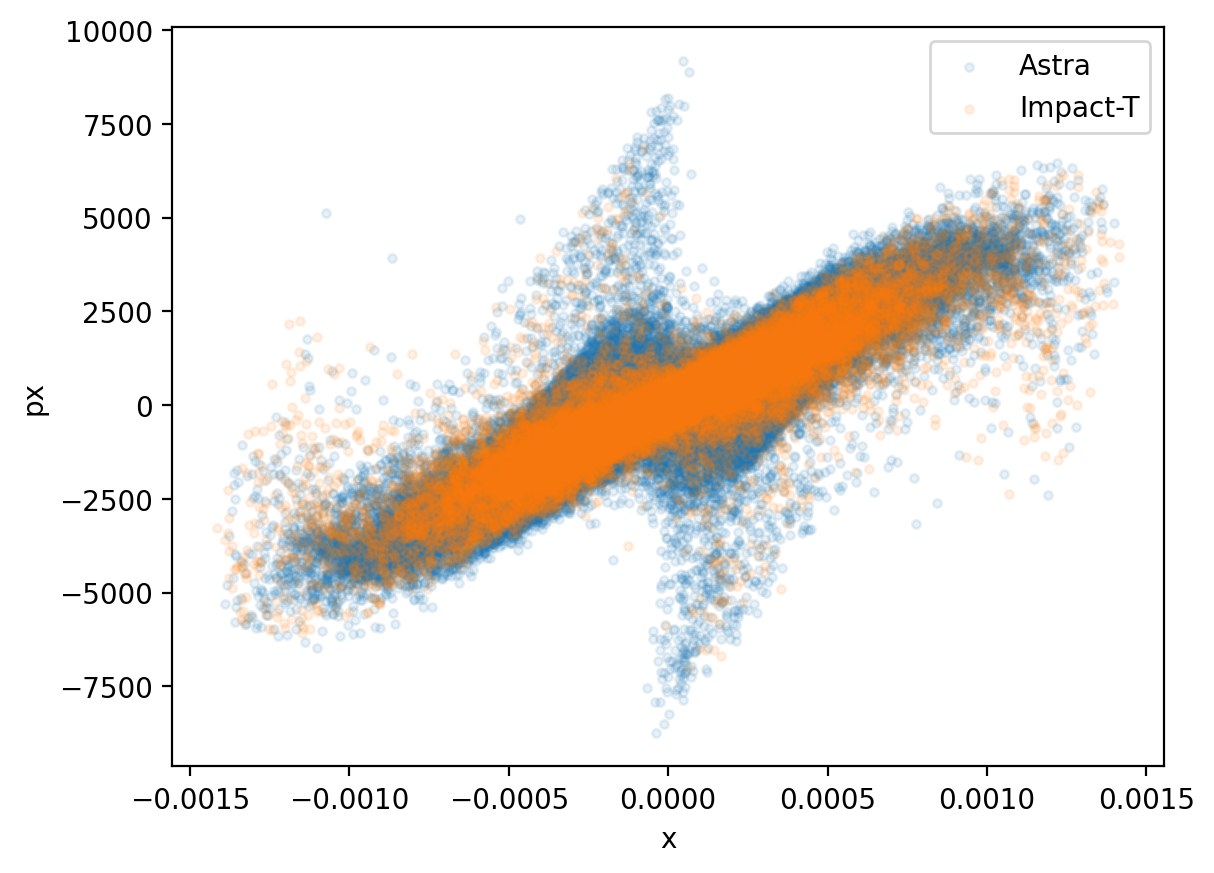

In [26]:
def compare_particles(key1, key2, skip=1):
    for name, P in (("Astra", Pa), ("Impact-T", Pi)):
        plt.scatter(P[key1][::skip], P[key2][::skip], marker='.', alpha=0.1, label=name)
        plt.xlabel(key1)
        plt.ylabel(key2)
    plt.legend()
        
compare_particles('x', 'px')        


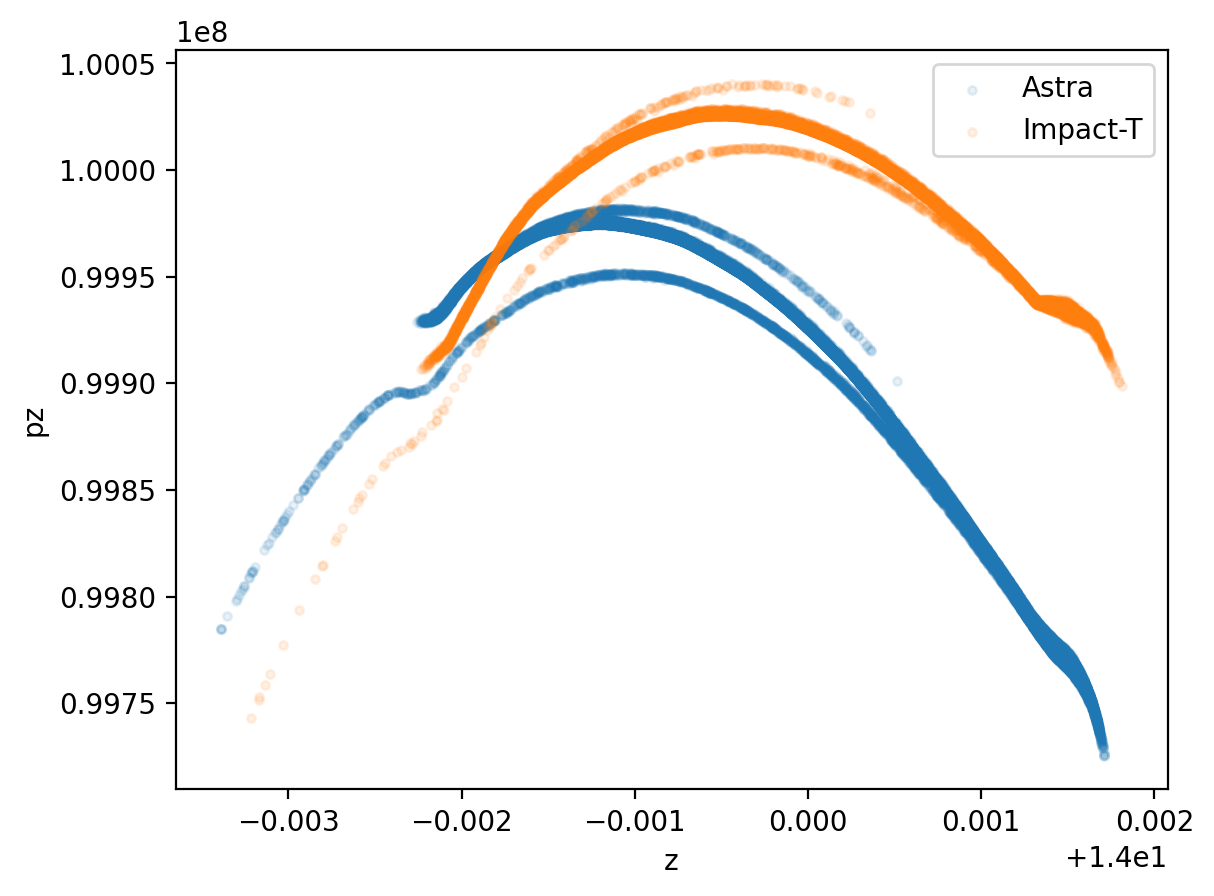

In [27]:
compare_particles('z', 'pz')  

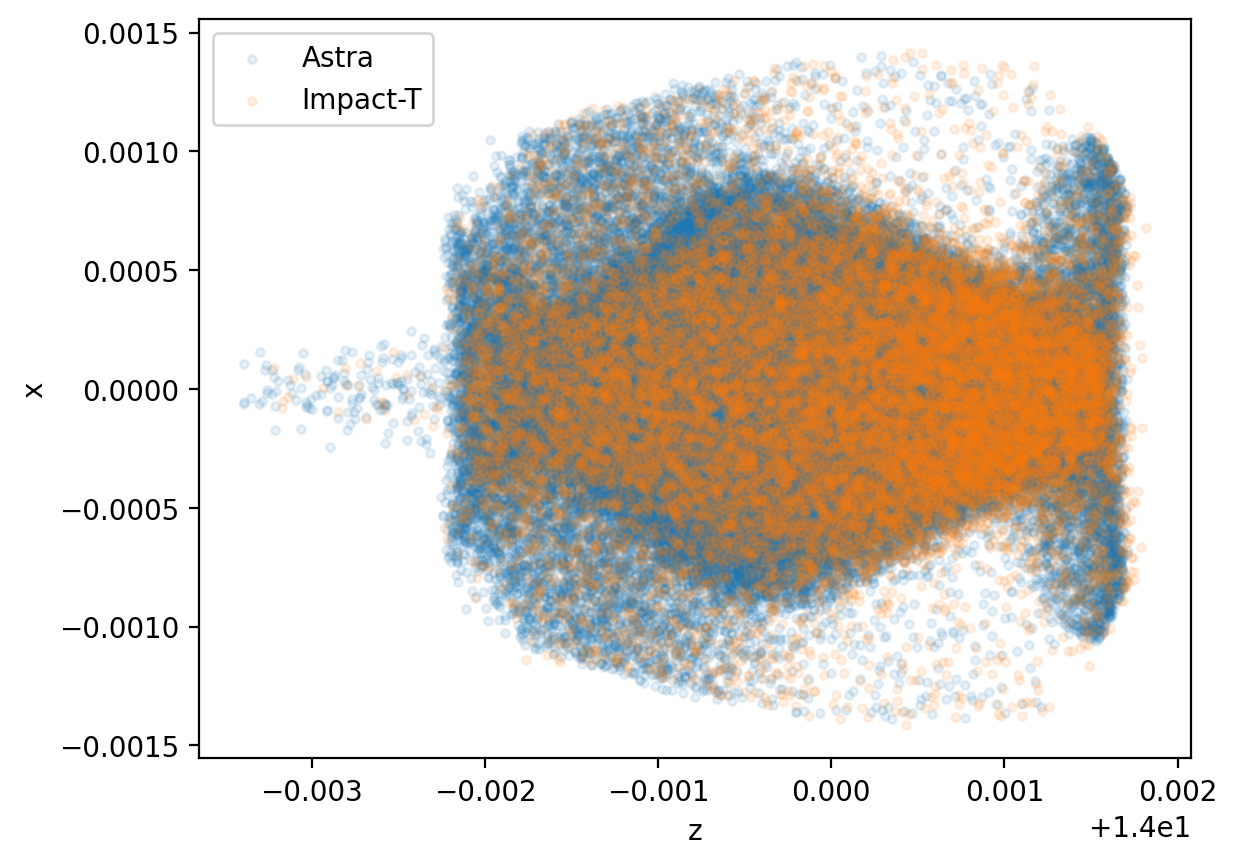

In [28]:
compare_particles('z', 'x')  

# Scan `CAVL011`

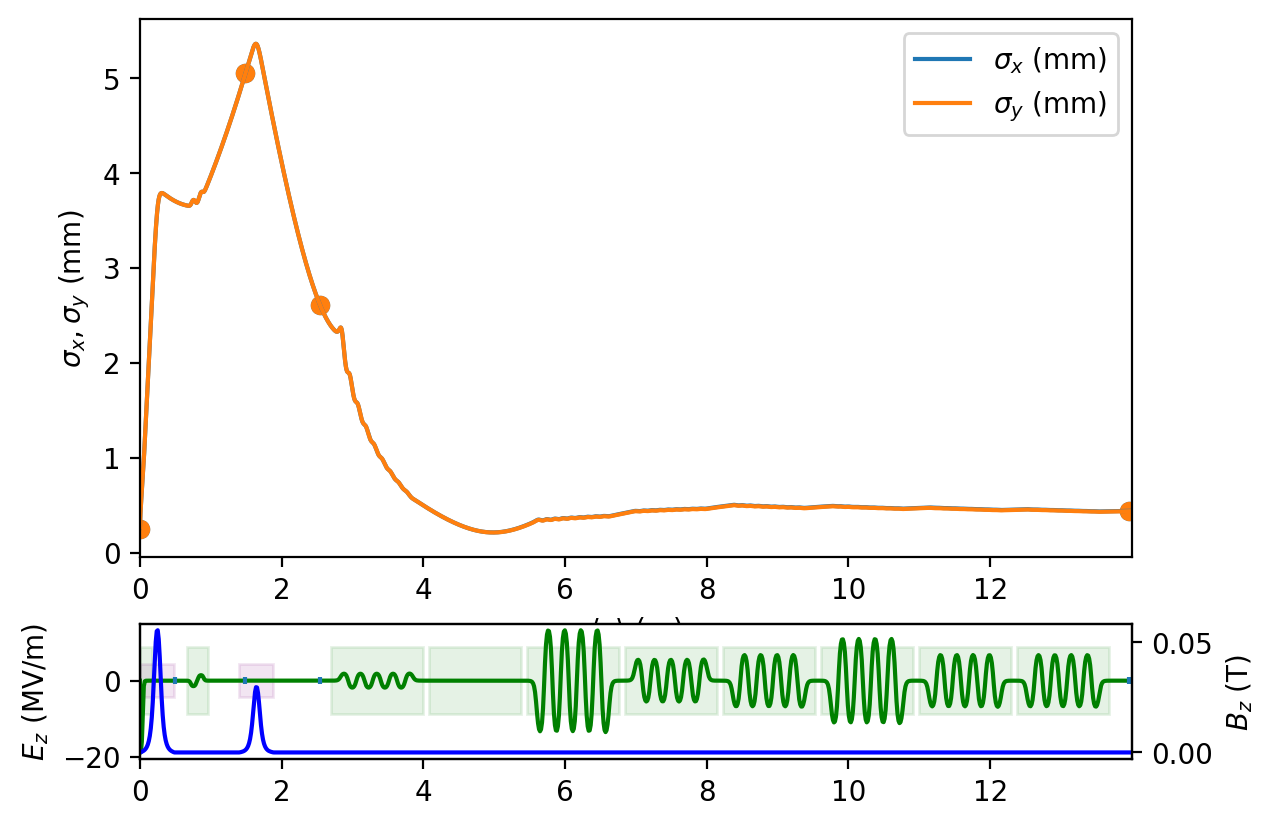

In [30]:
I.plot()

In [31]:
from concurrent.futures import ProcessPoolExecutor
# Allows processes to work with macOS
from sys import platform 
if platform == 'darwin':
    import multiprocessing as mp
    mp.set_start_method("fork")

In [32]:
Iref = I.copy()
Pref = I.particles['CM01BEG'].copy()
Iref.output = {}
x0 = Iref.ele['CAVL011']['theta0_deg']
x0

279.7872241485336

In [33]:
xlist = np.linspace(x0-10, x0+5, 8)
xlist

array([269.78722415, 271.93008129, 274.07293843, 276.21579558,
       278.35865272, 280.50150986, 282.64436701, 284.78722415])

In [34]:
%%time
def set1(x, ele='CAVL011', component='theta0_deg'): 
    I2 = Iref.copy()
    I2.verbose=False
    I2.configure()
    I2.numprocs = 1
    I2.ele[ele][component] = x
    I2.initial_particles = Pref
    I2.run()
    return I2

#I2 = set1(x0)

CPU times: user 1 µs, sys: 1 µs, total: 2 µs
Wall time: 2.86 µs


In [35]:
%%time
with ProcessPoolExecutor(max_workers=8) as executor:
    results1 = list(executor.map(set1, xlist))    

CPU times: user 102 ms, sys: 129 ms, total: 230 ms
Wall time: 24min 12s


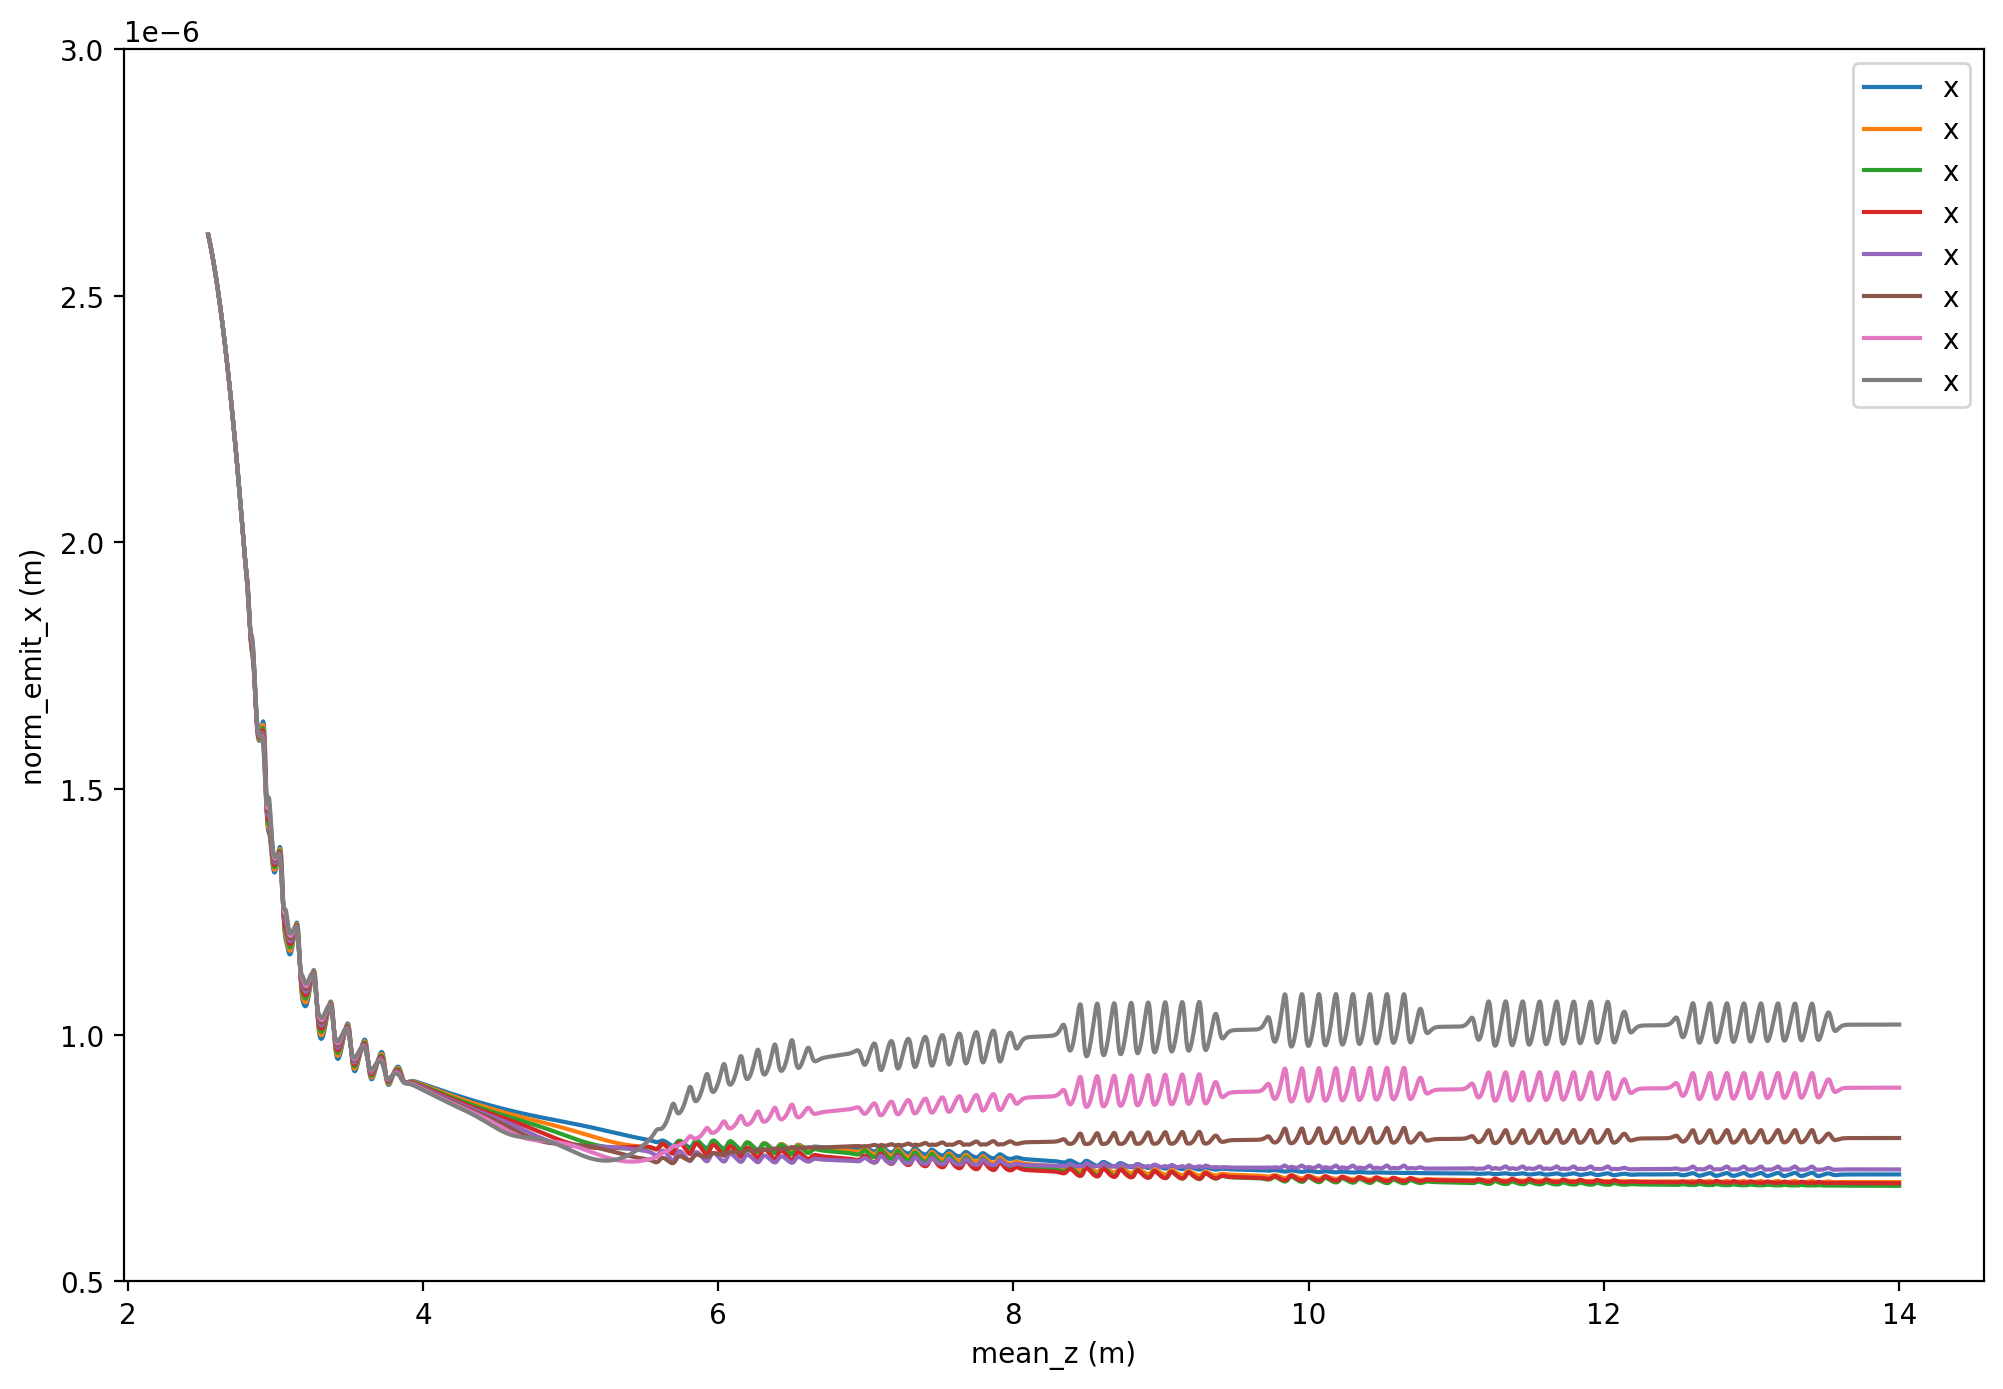

In [36]:
def compare(ykey, xkey = 'mean_z', ylim=None):
    xunits = I.units(xkey)
    yunits = I.units(ykey)
    
    fig, ax = plt.subplots(figsize=(12,8))
    
    for name, I9 in enumerate(results1):
        ax.plot(I9.stat(xkey), I9.stat(ykey), label='x')
    ax.set_xlabel(f'{xkey} ({xunits})')
    ax.set_ylabel(f'{ykey} ({yunits})')
    ax.set_ylim(ylim)
    plt.legend()
    
compare('norm_emit_x', ylim=(5e-7, 3e-6)    )
#plt.yscale('log')

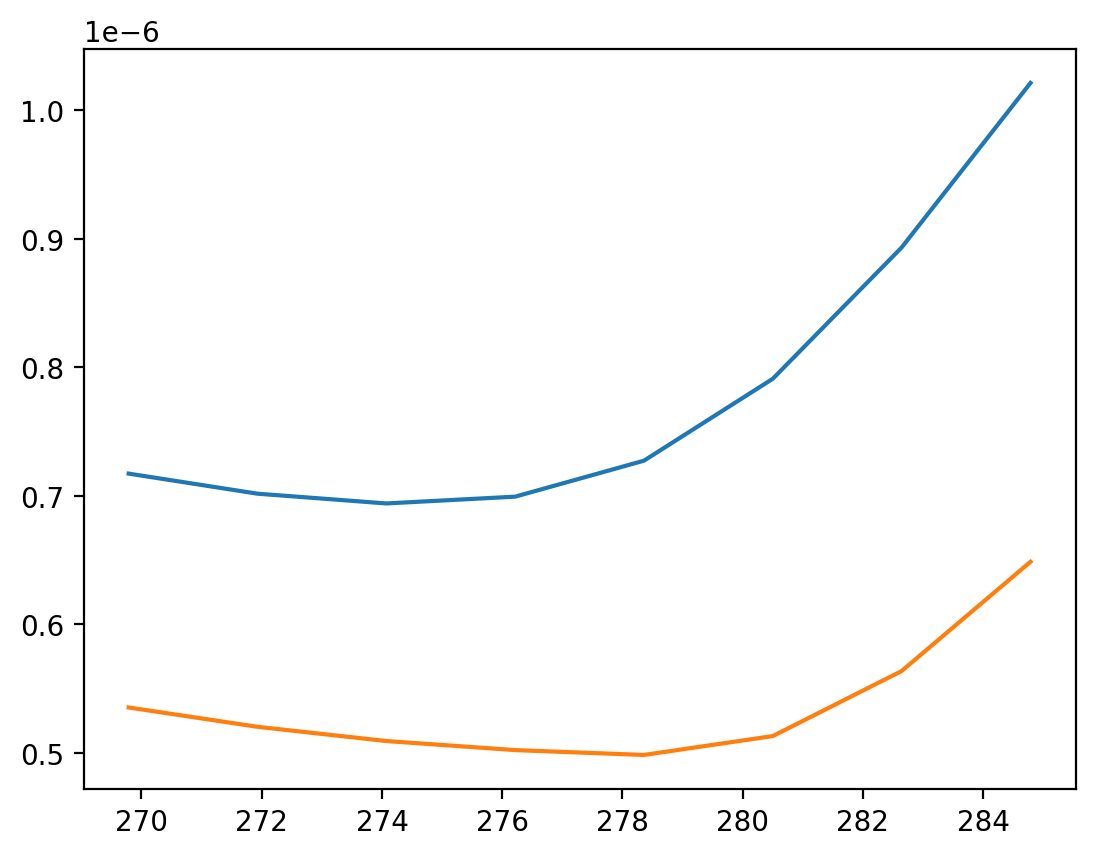

In [37]:
results1
y1 = np.array(list(map(lambda ii: ii.particles['final_particles'].twiss('x', 1)['norm_emit_x'], results1)))
y2 = np.array(list(map(lambda ii: ii.particles['final_particles'].twiss('x', 0.95)['norm_emit_x'], results1)))
plt.plot(xlist, y1)
plt.plot(xlist, y2)

In [38]:
y1.argmin()

2

In [39]:
xlist[3]

276.21579557710504

In [40]:
x0

279.7872241485336

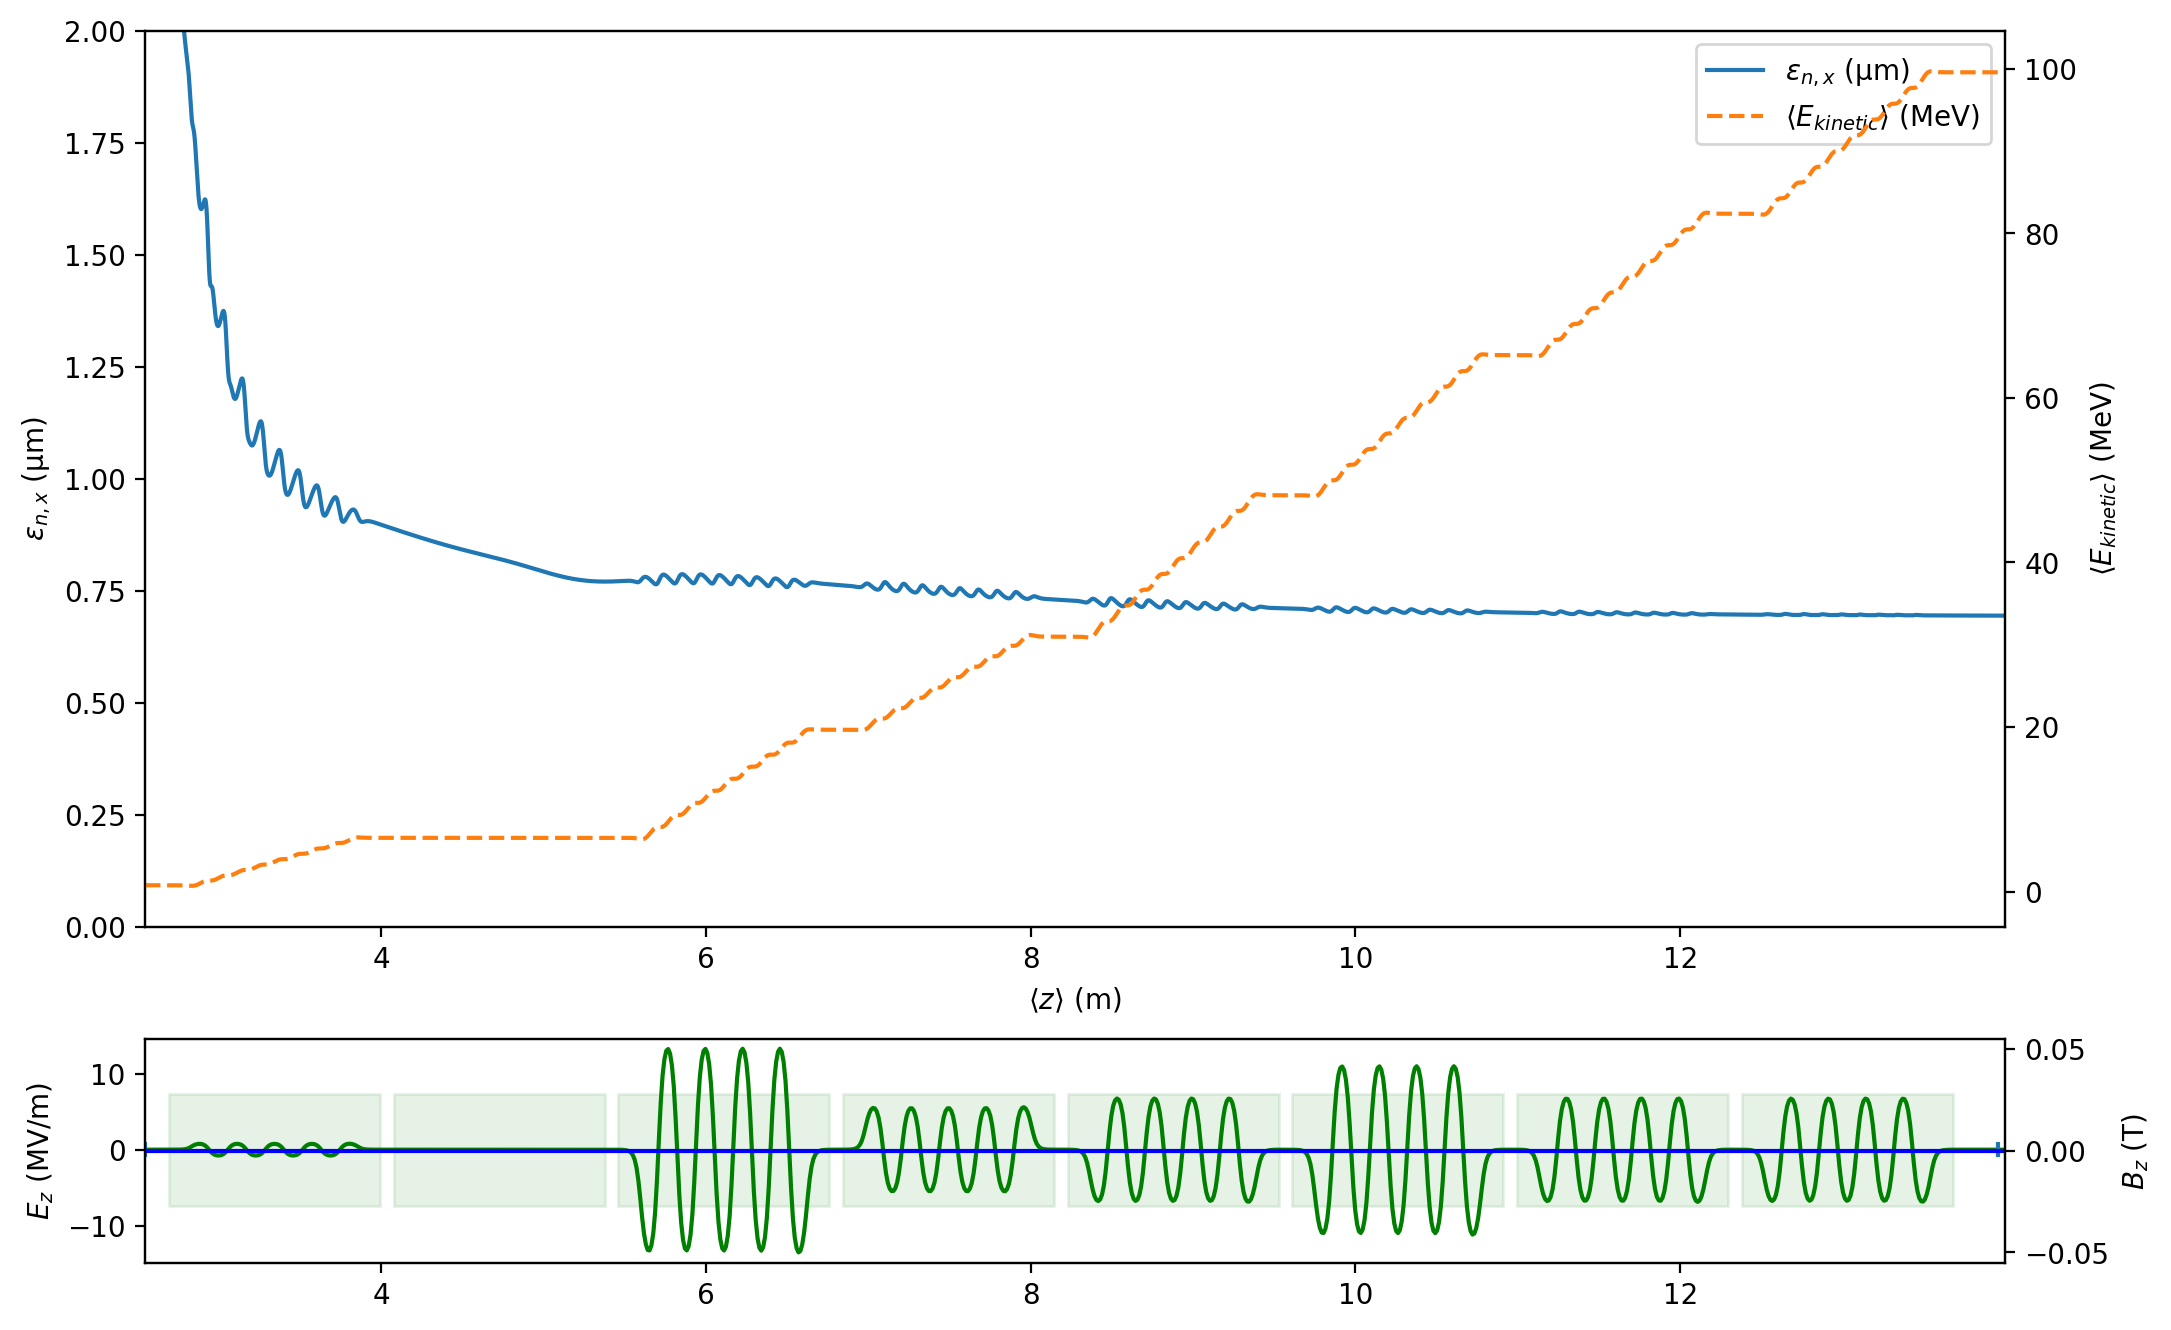

In [41]:
I9 = results1[y1.argmin()]
I9.plot('norm_emit_x', y2='mean_kinetic_energy', ylim=(0, 2e-6), figsize=(12,8))